VAMOS A PROBAR HACER UN MODELO QUE PERMITA VER LA UBICACION DE LOS MEJORES RESTAURANTES. UTILIZAMOS SOLO UN DATASET, RESTAURANTES_2020.

In [1]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ruta = r'C:\Users\franc\OneDrive\Escritorio\Henry\Cursado Henry\PF\ML\restaurantes csv\restaurantes_2020.csv'

restaruantes_2020 = pd.read_csv(ruta, sep=',', encoding='utf-8')

In [4]:
restaruantes_2020.head()

,id_nombre,nombre,direccion,id_ciudad,ciudad,codigo_postal,latitud,longitud,puntuacion_yelp,categories,puntuacion_usuarios,anio,analisis_sentimientos
0,0002,London Heights British Pub,7701 N Nebraska Ave,RGTW,Tampa,33664,28.017764,-82.451033,3.5,"Bars, Pubs, Sports Bars, Nightlife, Restaurant...",3.1,2020,1.0
1,0010,Orderqd,"4304 S Dale Mabry Hwy, Ste 1",RGTW,Tampa,33664,27.903033,-82.505446,4.5,"Burgers, Chicken Wings, Restaurants, Chicken S...",4.6,2020,1.0
2,0013,Chulas Mexican Grill,11061 Spring Hill Dr,I0WF,Spring Hill,34610,28.461770,-82.541448,3.5,"Mexican, Restaurants",3.0,2020,1.0
3,0015,Twistee Treat - Spring Hill II,1329 Commercial Way,I0WF,Spring Hill,34610,28.452841,-82.631433,3.5,"Food, Desserts, Restaurants, Ice Cream & Froze...",3.7,2020,1.0
4,0018,Mr. Dunderbak's,14929 Bruce B Downs Blvd,RGTW,Tampa,33664,28.083089,-82.411907,4.5,"Beer, Wine & Spirits, Food, Pubs, German, Amer...",4.6,2020,1.0


In [5]:
restaruantes_2020.describe()

,codigo_postal,latitud,longitud,puntuacion_yelp,puntuacion_usuarios,anio,analisis_sentimientos
count,3307.000000,3307.000000,3307.000000,3307.000000,3307.000000,3307.0,3307.000000
mean,33856.791956,28.000327,-82.561073,3.910644,3.912670,2020.0,0.973843
std,394.138676,0.139295,0.167528,0.619565,0.914023,0.0,0.115349
min,33511.000000,27.564457,-82.850318,1.000000,1.000000,2020.0,0.000000
25%,33664.000000,27.924423,-82.716526,3.500000,3.500000,2020.0,1.000000
50%,33664.000000,27.979695,-82.533148,4.000000,4.000000,2020.0,1.000000
75%,33778.000000,28.061142,-82.450141,4.500000,4.600000,2020.0,1.000000
max,34698.000000,28.494629,-82.104874,5.000000,5.000000,2020.0,1.000000


C:\Users\franc\AppData\Local\Temp\ipykernel_2248\820706761.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['cluster'] = kmeans.fit_predict(data[['latitud', 'longitud']])


cluster
0    3.966221
1    3.967491
2    3.715162
3    3.900778
4    3.956029
Name: puntuacion_usuarios, dtype: float64


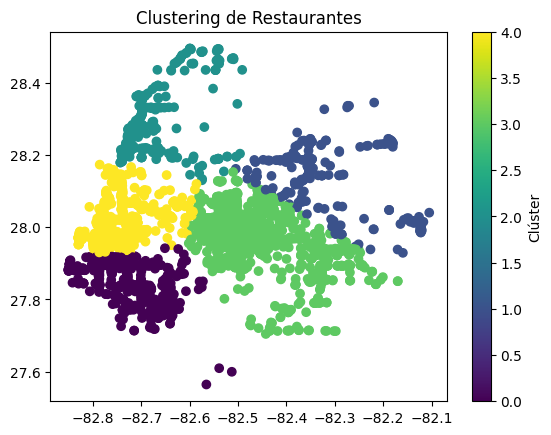

In [6]:
# Ejemplo con pandas y sklearn
data = restaruantes_2020[['latitud','longitud','puntuacion_usuarios']]

# Entrenar modelo KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
data['cluster'] = kmeans.fit_predict(data[['latitud', 'longitud']])

# Promedio de puntuaciones por clúster
cluster_scores = data.groupby('cluster')['puntuacion_usuarios'].mean()
print(cluster_scores)

# Visualización básica
plt.scatter(data['longitud'], data['latitud'], c=data['cluster'], cmap='viridis')
plt.colorbar(label='Clúster')
plt.title('Clustering de Restaurantes')
plt.show()


NO TRAE NINGUNA VISUALIZACION QUE SEA ENTENDIBLE TAL Y COMO ESTA, AJUSTAR.

VAMOS A PROBAR CON UN MODELO PREDICTIVO (ARBOL DE DECISION)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:
# Crear objetivo binario
data['is_good'] = (restaruantes_2020['puntuacion_usuarios'] >= 4.5).astype(int)

# Dividir datos
X = data[['latitud', 'longitud']]
y = data['is_good']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predicciones
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


C:\Users\franc\AppData\Local\Temp\ipykernel_2248\4098802019.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['is_good'] = (restaruantes_2020['puntuacion_usuarios'] >= 4.5).astype(int)


              precision    recall  f1-score   support

           0       0.68      0.78      0.73       451
           1       0.30      0.19      0.23       211

    accuracy                           0.60       662
   macro avg       0.49      0.49      0.48       662
weighted avg       0.55      0.60      0.57       662



ESTE MODELO PREDICE SI EL RESTAURANT VA A SER BUENO (4.5 DE PUNTUACION DE USUARIO) O NO EN BASE A LA UBICACION GEOGRAFICA. PODEMOS VER QUE LA PREDICCION DE LOS BUENOS RESTAURANTES NO ES BUENA (%30 DE PRECISION).